=== Tugas 1: Data Cleaning ===
Shape: (1460, 81)
Jumlah Kolom: 81

Top 5 Missing Values:
 PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64


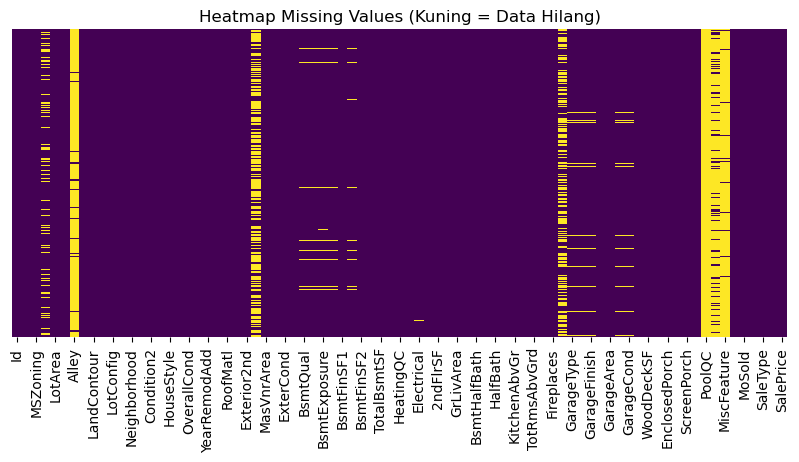


Jumlah duplikat awal: 0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Tugas 1: Data Cleaning ===")
# 1. Load data
df = pd.read_csv('train.csv')

# Info dasar
print(f"Shape: {df.shape}")
print(f"Jumlah Kolom: {len(df.columns)}")

# 2. Identifikasi & Visualisasi Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nTop 5 Missing Values:\n", missing.head(5))

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Values (Kuning = Data Hilang)')
plt.show()

# 3. Handling Missing Values (3 Strategi)
# Strategi A: Drop kolom yang hampir kosong semua
df_clean = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])

# Strategi B: Imputasi Median (untuk kolom numerik LotFrontage)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

# Strategi C: Imputasi Modus (untuk kolom kategorikal MasVnrType)
df_clean['MasVnrType'] = df_clean['MasVnrType'].fillna(df_clean['MasVnrType'].mode()[0])

# 4. Remove Duplicates
print(f"\nJumlah duplikat awal: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print("="*50)


=== Tugas 2: Outlier Handling ===


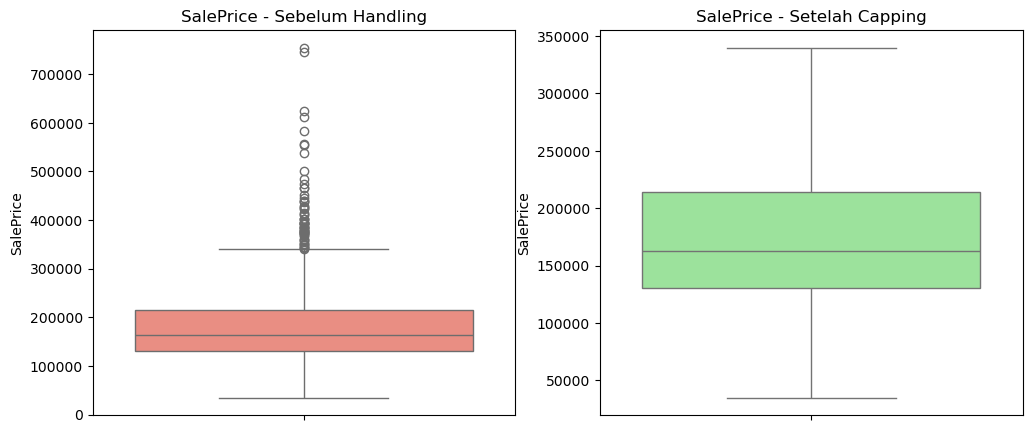

Data setelah Outlier Removal: 1399 baris


In [3]:
print("\n=== Tugas 2: Outlier Handling ===")
# Pilih 3 kolom numerik
cols_check = ['SalePrice', 'GrLivArea', 'LotArea']

def get_bounds(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Visualisasi Before (SalePrice)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['SalePrice'], color='salmon')
plt.title('SalePrice - Sebelum Handling')

# Handling 1: Capping (Membatasi nilai)
low, high = get_bounds(df_clean, 'SalePrice')
df_capped = df_clean.copy()
df_capped['SalePrice'] = np.clip(df_capped['SalePrice'], low, high)

# Handling 2: Removal (Menghapus baris)
df_removed = df_clean[(df_clean['SalePrice'] >= low) & (df_clean['SalePrice'] <= high)]

plt.subplot(1, 2, 2)
sns.boxplot(y=df_capped['SalePrice'], color='lightgreen')
plt.title('SalePrice - Setelah Capping')
plt.show()

print(f"Data setelah Outlier Removal: {len(df_removed)} baris")
print("="*50)


=== Tugas 3: Normalisasi & Standardisasi ===


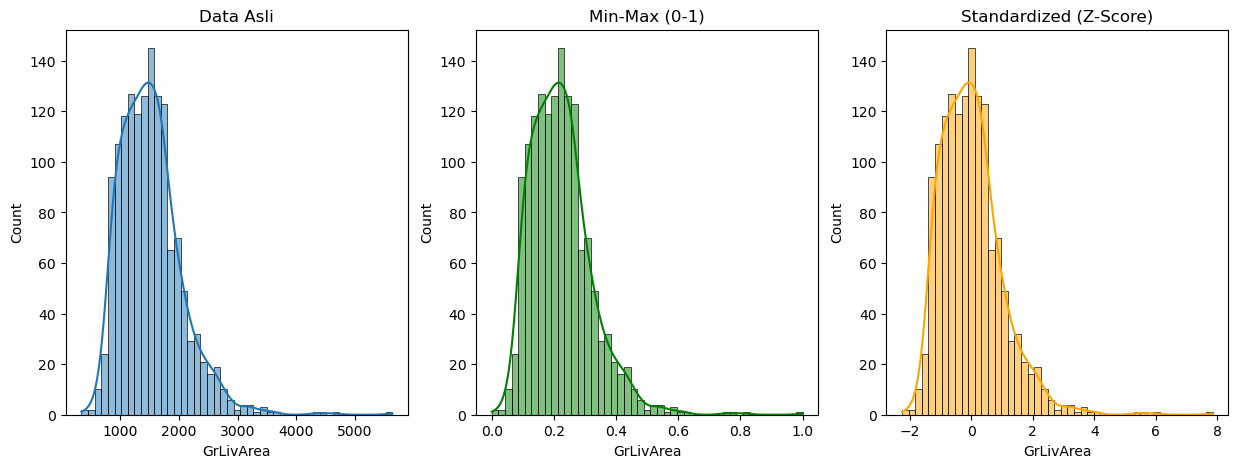

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("\n=== Tugas 3: Normalisasi & Standardisasi ===")
num_cols = ['LotArea', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
subset = df_clean[num_cols].fillna(0)

# 1. Normalisasi (0-1)
scaler_mm = MinMaxScaler()
df_norm = pd.DataFrame(scaler_mm.fit_transform(subset), columns=num_cols)

# 2. Standardisasi (Mean=0, Std=1)
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(subset), columns=num_cols)

# Visualisasi Perbandingan pada GrLivArea
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); sns.histplot(subset['GrLivArea'], kde=True); plt.title('Data Asli')
plt.subplot(1, 3, 2); sns.histplot(df_norm['GrLivArea'], kde=True, color='green'); plt.title('Min-Max (0-1)')
plt.subplot(1, 3, 3); sns.histplot(df_std['GrLivArea'], kde=True, color='orange'); plt.title('Standardized (Z-Score)')
plt.show()
print("="*50)


=== Tugas 4: Exploratory Data Analysis (EDA) ===


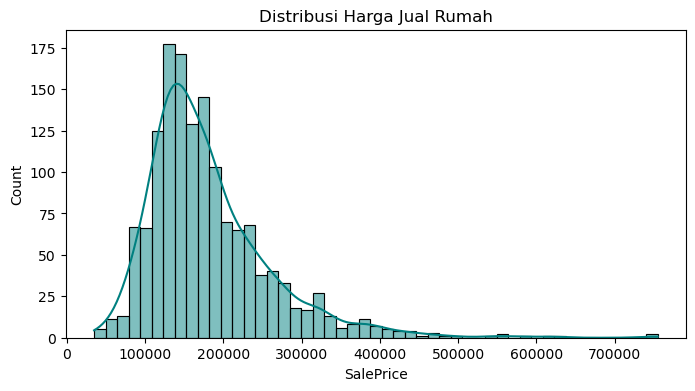

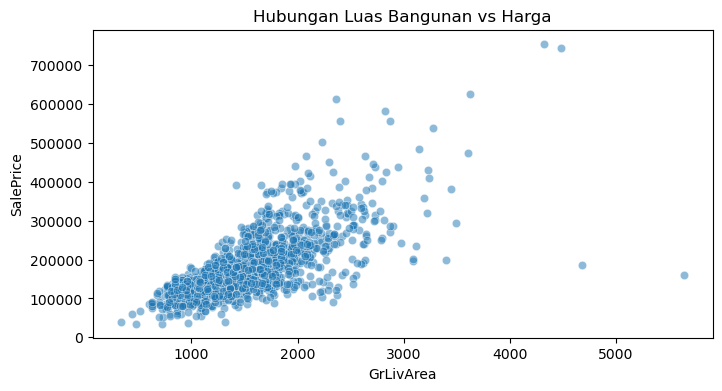

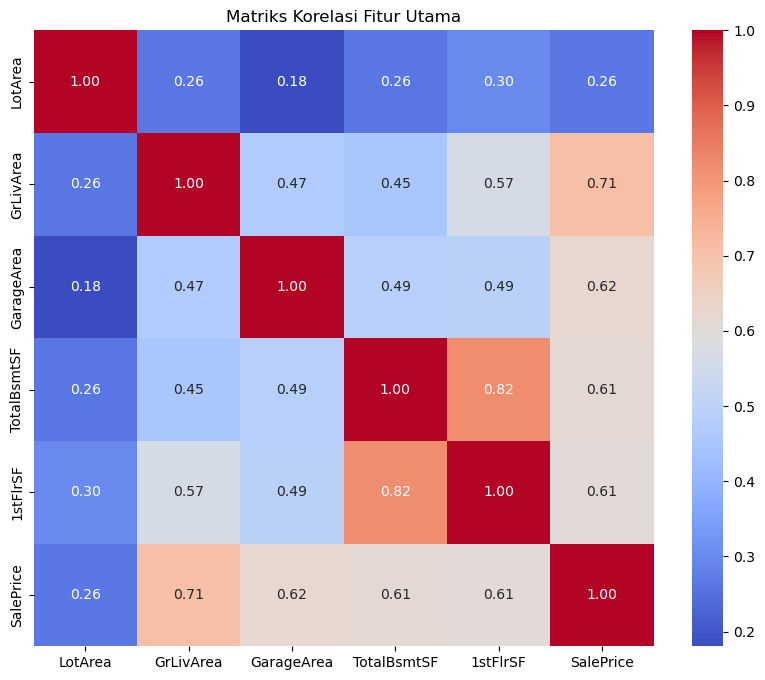


Insights:
1. SalePrice memiliki distribusi miring ke kanan (positively skewed).
2. GrLivArea memiliki korelasi positif yang sangat kuat dengan SalePrice (0.71).
3. Terdapat banyak pencilan (outliers) pada data harga di atas $400,000.
4. Luas garasi (GarageArea) juga berpengaruh signifikan terhadap harga jual.
5. Banyak fitur fasilitas tambahan (seperti kolam renang) yang datanya kosong.


In [5]:
print("\n=== Tugas 4: Exploratory Data Analysis (EDA) ===")

# 1. Univariate Analysis (Distribusi Harga)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['SalePrice'], kde=True, color='teal')
plt.title('Distribusi Harga Jual Rumah')
plt.show()

# 2. Bivariate Analysis (Hubungan Luas vs Harga)
plt.figure(figsize=(8, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_clean, alpha=0.5)
plt.title('Hubungan Luas Bangunan vs Harga')
plt.show()

# 3. Multivariate (Correlation Heatmap)
plt.figure(figsize=(10, 8))
corr = df_clean[num_cols + ['SalePrice']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Utama')
plt.show()

print("\nInsights:")
print("1. SalePrice memiliki distribusi miring ke kanan (positively skewed).")
print("2. GrLivArea memiliki korelasi positif yang sangat kuat dengan SalePrice (0.71).")
print("3. Terdapat banyak pencilan (outliers) pada data harga di atas $400,000.")
print("4. Luas garasi (GarageArea) juga berpengaruh signifikan terhadap harga jual.")
print("5. Banyak fitur fasilitas tambahan (seperti kolam renang) yang datanya kosong.")